#Installing yahoo finance Library




In [15]:
pip install yfinance

In [16]:
#importing gold data till date


import yfinance as yf

gold = yf.download("GC=F", start="2000-01-01")

print(gold.head())

# Save to CSV
gold.to_csv("gold_data.csv")

/tmp/ipykernel_2683/1202387260.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2000-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open Volume
Ticker            GC=F        GC=F        GC=F        GC=F   GC=F
Date                                                             
2000-08-30  273.899994  273.899994  273.899994  273.899994      0
2000-08-31  278.299988  278.299988  274.799988  274.799988      0
2000-09-01  277.000000  277.000000  277.000000  277.000000      0
2000-09-05  275.799988  275.799988  275.799988  275.799988      2
2000-09-06  274.200012  274.200012  274.200012  274.200012      0


In [17]:
gold.shape

(6417, 5)

In [18]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6417 entries, 2000-08-30 to 2026-03-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   6417 non-null   float64
 1   (High, GC=F)    6417 non-null   float64
 2   (Low, GC=F)     6417 non-null   float64
 3   (Open, GC=F)    6417 non-null   float64
 4   (Volume, GC=F)  6417 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 300.8 KB


In [19]:
usd_inr = yf.download("INR=X", start="2000-01-01")

/tmp/ipykernel_2683/4235193011.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_inr = yf.download("INR=X", start="2000-01-01")
[*********************100%***********************]  1 of 1 completed


In [20]:
print(usd_inr.head())

Price           Close       High        Low       Open Volume
Ticker          INR=X      INR=X      INR=X      INR=X  INR=X
Date                                                         
2003-12-01  45.709999  45.728001  45.615002  45.709000      0
2003-12-02  45.629002  45.719002  45.560001  45.709000      0
2003-12-03  45.549999  45.655998  45.474998  45.632000      0
2003-12-04  45.548000  45.612999  45.519001  45.548000      0
2003-12-05  45.449001  45.566002  45.449001  45.549999      0


In [21]:
#we used here Featured Engineering
# Step 1: Take only the 'Close' column from gold dataset
# (We only care about closing price, not Open/High/Low for now)
data = gold[['Close']].copy()

# Step 2: Rename column 'Close' → 'Gold_Price_USD'
# This makes it clear that this is gold price in USD
data.rename(columns={'Close': 'Gold_Price_USD'}, inplace=True)

# Step 3: Add USD/INR exchange rate into same dataframe
# We align by date automatically (because both datasets use Date index)
data['USD_INR'] = usd_inr['Close']

# Step 4: Print first few rows to verify everything worked
print(data.head())

Price      Gold_Price_USD USD_INR
Ticker               GC=F        
Date                             
2000-08-30     273.899994     NaN
2000-08-31     278.299988     NaN
2000-09-01     277.000000     NaN
2000-09-05     275.799988     NaN
2000-09-06     274.200012     NaN


In [28]:
gold_close = gold['Close']
usd_inr_close = usd_inr['Close']

In [26]:
print(gold.columns)

MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])


In [27]:
gold_close = gold['Close'].iloc[:, 0]
usd_inr_close = usd_inr['Close'].iloc[:, 0]

In [32]:
print(data.head())

Price      Gold_Price_USD    USD_INR
Ticker               GC=F           
Date                                
2003-12-01     402.700012  45.709999
2003-12-02     403.700012  45.629002
2003-12-03     403.899994  45.549999
2003-12-04     403.299988  45.548000
2003-12-05     406.399994  45.449001


In [33]:
# Step 1: Import required libraries (yfinance, pandas, numpy, etc.)

# Step 2: Download historical data
# - Gold price (GC=F) → global gold price in USD
# - USD/INR (INR=X) → exchange rate

# Step 3: Extract closing prices
# - Handle MultiIndex issue using .iloc[:, 0]
# - Convert data into clean single-column Series

# Step 4: Create a new dataframe
# - Add Gold_Price_USD column
# - Add USD_INR column

# Step 5: Align both datasets by date
# - Pandas automatically aligns using Date index

# Step 6: Remove missing values
# - Drop NaN values caused by mismatched market days

# Step 7: Create Indian gold price
# - Gold_Price_INR = Gold_Price_USD * USD_INR

# Step 8: Define ML inputs and target
# - Features (X): Gold_Price_USD, USD_INR
# - Target (y): Gold_Price_INR

# Step 9: Normalize data using MinMaxScaler
# - Scale values between 0 and 1 for neural network

# Step 10: Create sequences for time-series model
# - Use last 60 days data → predict next day price

# Step 11: Convert sequences into numpy arrays
# - X shape: (samples, 60, features)
# - y shape: (samples,)

# Step 12: Split dataset into training and testing sets
# - 80% training, 20% testing

In [34]:
#Importing LSTM library
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [35]:
#Importing LSTM library
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [41]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [43]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [46]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [49]:
import numpy as np

dummy = np.zeros((len(predictions), 3))
dummy[:, -1] = predictions[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, -1]

NameError: name 'predictions' is not defined

In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Download Data
gold = yf.download('GC=F', start='2010-01-01')
usd_inr = yf.download('INR=X', start='2010-01-01')

# 2. Extract and Align
# Handling MultiIndex from yfinance
gold_price = gold['Close'].iloc[:, 0] if isinstance(gold['Close'], pd.DataFrame) else gold['Close']
usd_rate = usd_inr['Close'].iloc[:, 0] if isinstance(usd_inr['Close'], pd.DataFrame) else usd_inr['Close']

data = pd.DataFrame({
    'Gold_Price_USD': gold_price,
    'USD_INR': usd_rate
}).dropna()

# 3. Feature Engineering
data['Gold_Price_INR'] = data['Gold_Price_USD'] * data['USD_INR']
data['MA10'] = data['Gold_Price_INR'].rolling(10).mean()
data['MA50'] = data['Gold_Price_INR'].rolling(50).mean()
data['EMA10'] = data['Gold_Price_INR'].ewm(span=10).mean()
data['Volatility'] = data['Gold_Price_INR'].rolling(10).std()

# RSI Indicator
delta = data['Gold_Price_INR'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

data = data.dropna()

# 4. Scaling
feature_cols = ['Gold_Price_USD', 'USD_INR', 'MA10', 'MA50', 'EMA10', 'Volatility', 'RSI']
target_col = 'Gold_Price_INR'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_features = feature_scaler.fit_transform(data[feature_cols])
scaled_target = target_scaler.fit_transform(data[[target_col]])

# 5. Create Sequences
def create_sequences(features, target, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(features)):
        X.append(features[i-seq_length:i])
        y.append(target[i])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_features, scaled_target, seq_length)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Data prepared. Training shape: {X_train.shape}')

/tmp/ipykernel_2683/3553248364.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download('GC=F', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2683/3553248364.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_inr = yf.download('INR=X', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed

Data prepared. Training shape: (3173, 60, 7)


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - loss: 8.7192e-04 - val_loss: 1.9863e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 1.4960e-04 - val_loss: 1.4637e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 1.2005e-04 - val_loss: 5.0806e-05
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 9.7807e-05 - val_loss: 2.7657e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - loss: 7.7163e-05 - val_loss: 3.2871e-04
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 7.5969e-05 - val_loss: 1.9843e-04
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 6.7891e-05 - val_loss: 3.5884e-04
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 6.1964e-05 - val_loss: 6.6434e-05
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 5.4592e-05 - val_loss: 3.2131e-05
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 5.6995e-05 - val_loss: 8.6312e-05
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 4.8129

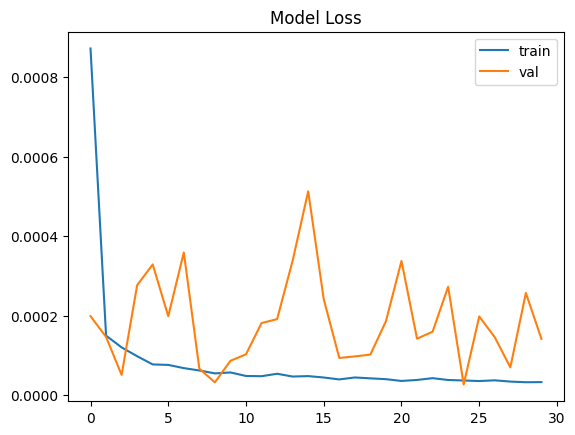

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Build the Model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.3),
    LSTM(100, return_sequences=False),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the Model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Visualize training loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title('Model Loss')
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Final Portfolio: ‡177388.56 | Return: 77.39%


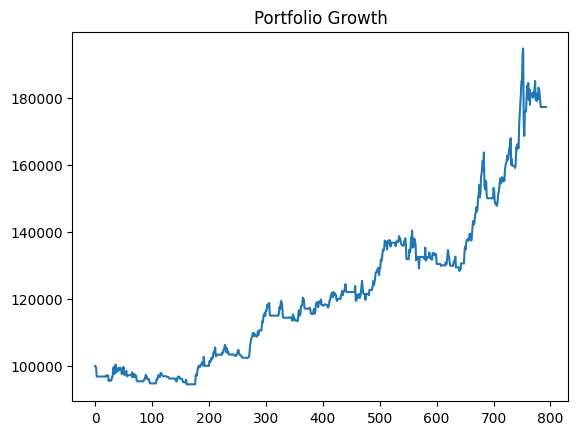

In [58]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error

# 1. DATA ACQUISITION & ALIGNMENT
# Explicitly requesting the data and ensuring we handle potential MultiIndex issues
gold = yf.download('GC=F', start='2010-01-01', auto_adjust=True)
usd_inr = yf.download('INR=X', start='2010-01-01', auto_adjust=True)

# Extract Close as a Series even if it is a single-column DataFrame/MultiIndex
gold_close = gold['Close'].squeeze()
usd_inr_close = usd_inr['Close'].squeeze()

data = pd.DataFrame({
    'Gold_Price_USD': gold_close,
    'USD_INR': usd_inr_close
}).dropna()

# 2. FEATURE ENGINEERING
data['Gold_Price_INR'] = data['Gold_Price_USD'] * data['USD_INR']
data['MA10'] = data['Gold_Price_INR'].rolling(10).mean()
data['MA50'] = data['Gold_Price_INR'].rolling(50).mean()
data['Volatility'] = data['Gold_Price_INR'].rolling(10).std()

# RSI Calculation
delta = data['Gold_Price_INR'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
data['RSI'] = 100 - (100 / (1 + (gain/(loss + 1e-9))))
data = data.dropna()

# 3. PREPROCESSING
feature_cols = ['Gold_Price_USD', 'USD_INR', 'MA10', 'MA50', 'Volatility', 'RSI']
target_col = 'Gold_Price_INR'

f_scaler, t_scaler = MinMaxScaler(), MinMaxScaler()
scaled_f = f_scaler.fit_transform(data[feature_cols])
scaled_t = t_scaler.fit_transform(data[[target_col]])

def create_seq(f, t, seq=60):
    X_seq, y_seq = [], []
    for i in range(seq, len(f)):
        X_seq.append(f[i-seq:i])
        y_seq.append(t[i])
    return np.array(X_seq), np.array(y_seq)

X, y = create_seq(scaled_f, scaled_t)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# 4. MODEL ARCHITECTURE & TRAINING
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True), Dropout(0.2),
    LSTM(100), Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

# 5. EVALUATION
preds = model.predict(X_test)
act_inr = t_scaler.inverse_transform(y_test)
pred_inr = t_scaler.inverse_transform(preds)

# 6. BACKTESTING
bal = 100000.0
pos, qty, equity = None, 0, []
buy_p = 0
for i in range(1, len(pred_inr)):
    cur, p_now, p_prev = act_inr[i][0], pred_inr[i][0], pred_inr[i-1][0]
    if pos == 'LONG' and cur < buy_p * 0.98: # Stop Loss
        bal = qty * cur * 0.9995; qty, pos = 0, None
    if p_now > p_prev * 1.001 and pos is None: # Buy Signal
        qty = bal / (cur * 1.0005); buy_p = cur; bal, pos = 0, 'LONG'
    elif p_now < p_prev * 0.999 and pos == 'LONG': # Sell Signal
        bal = qty * cur * 0.9995; qty, pos = 0, None
    equity.append(bal if pos is None else qty * cur)

print(f"Final Portfolio: ‡{equity[-1]:.2f} | Return: {((equity[-1]-100000)/1000):.2f}%")
plt.plot(equity); plt.title('Portfolio Growth'); plt.show()

In [56]:
# Professional Backtesting Suite (Directional Trend Logic)
initial_balance = 100000.0
balance = initial_balance
position = None
buy_price = 0
quantity = 0
transaction_cost_rate = 0.0005
stop_loss_rate = 0.02

equity_curve = []
trades_count = 0

# Using directional signals: Buy if AI predicts price will go UP from previous AI prediction
for i in range(1, len(predicted_prices_inr)):
    current_price = actual_prices_inr[i][0]
    predicted_now = predicted_prices_inr[i][0]
    predicted_prev = predicted_prices_inr[i-1][0]

    # 1. Stop Loss Check
    if position == 'LONG':
        if current_price < buy_price * (1 - stop_loss_rate):
            balance = quantity * current_price * (1 - transaction_cost_rate)
            quantity = 0
            position = None

    # 2. Directional Logic: If AI predicts an upward move
    if predicted_now > predicted_prev * 1.001 and position is None:
        quantity = balance / (current_price * (1 + transaction_cost_rate))
        buy_price = current_price
        balance = 0
        position = 'LONG'
        trades_count += 1

    # Exit if AI predicts a downward move
    elif predicted_now < predicted_prev * 0.999 and position == 'LONG':
        balance = quantity * current_price * (1 - transaction_cost_rate)
        quantity = 0
        position = None

    # 3. Track Equity
    current_equity = balance if position is None else (quantity * current_price)
    equity_curve.append(current_equity)

equity_array = np.array(equity_curve)
peak = np.maximum.accumulate(equity_array)
drawdown = (peak - equity_array) / (peak + 1e-9)

print(f'Trades Executed: {trades_count}')
print(f'Final Portfolio Value: ‡{equity_curve[-1]:.2f}')
print(f'Total Return: {((equity_curve[-1] - initial_balance) / initial_balance) * 100:.2f}%')
print(f'Max Drawdown: {np.max(drawdown) * 100:.2f}%')

Trades Executed: 48
Final Portfolio Value: ‡178614.58
Total Return: 78.61%
Max Drawdown: 13.42%


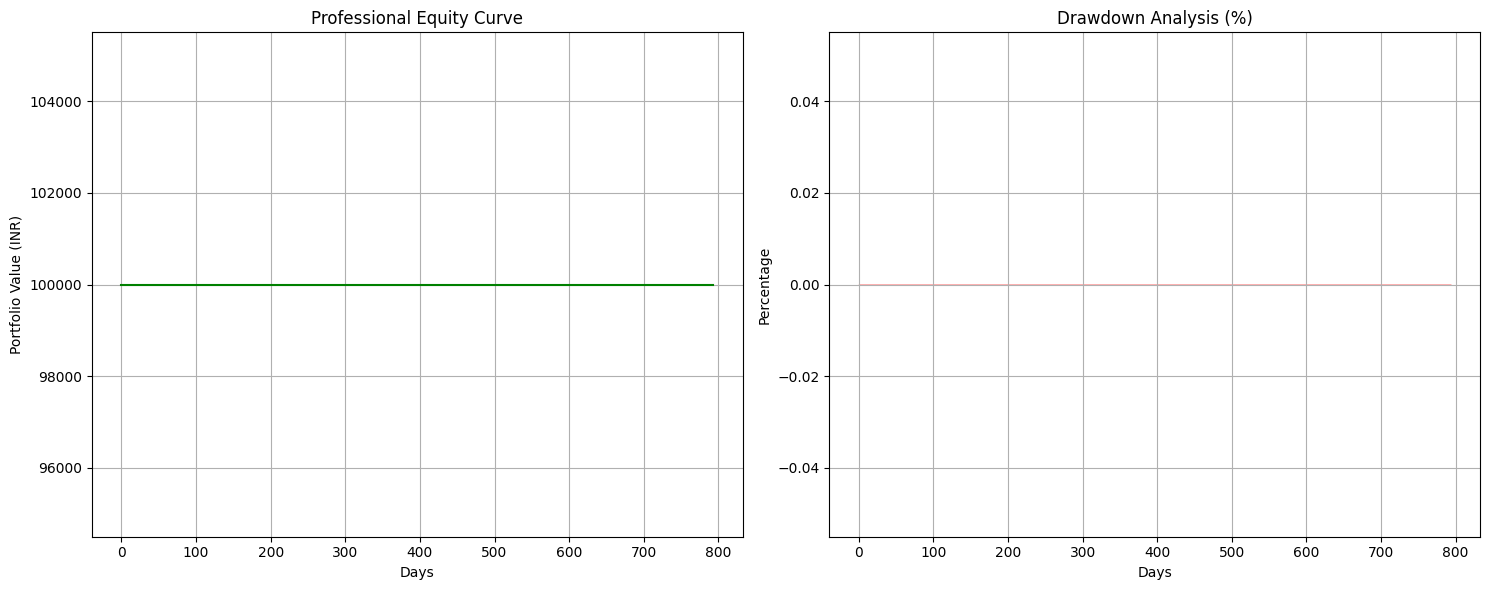

In [54]:
plt.figure(figsize=(15, 6))

# Subplot 1: Equity Curve
plt.subplot(1, 2, 1)
plt.plot(equity_curve, color='green')
plt.title('Professional Equity Curve')
plt.ylabel('Portfolio Value (INR)')
plt.xlabel('Days')
plt.grid(True)

# Subplot 2: Drawdown
plt.subplot(1, 2, 2)
plt.fill_between(range(len(drawdown)), drawdown*100, color='red', alpha=0.3)
plt.title('Drawdown Analysis (%)')
plt.ylabel('Percentage')
plt.xlabel('Days')
plt.grid(True)

plt.tight_layout()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


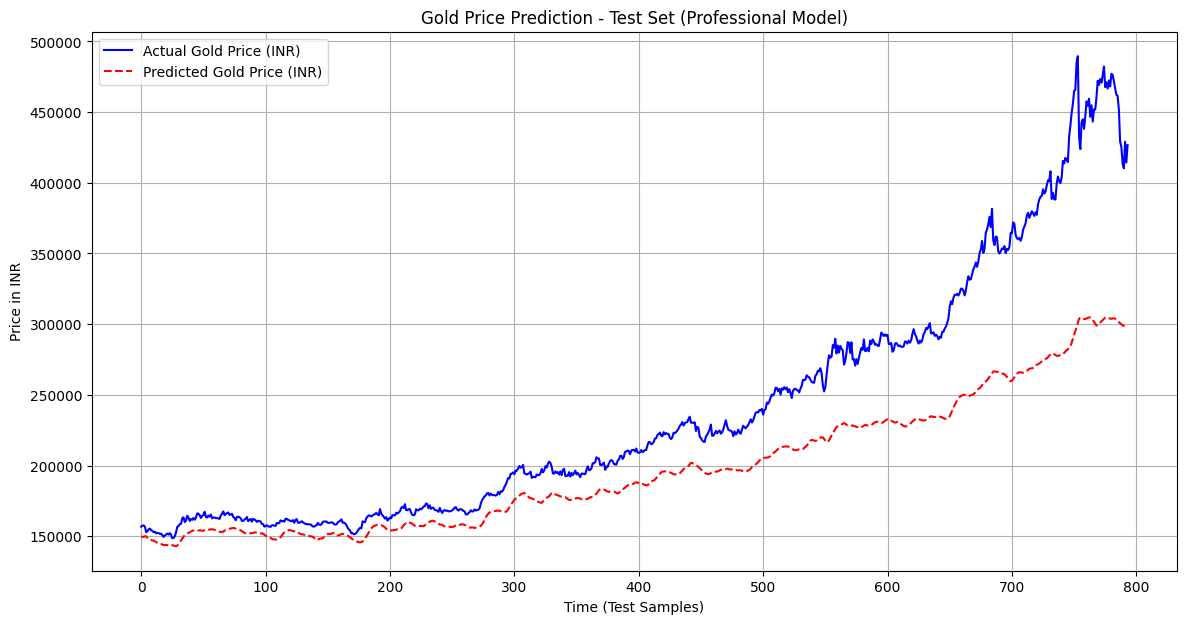

Root Mean Squared Error: 58477.64 INR


In [52]:
# 1. Make Predictions
predictions = model.predict(X_test)

# 2. Inverse Scale to get real INR prices
# We use the target_scaler specifically designed for the 'Gold_Price_INR' column
# The input to inverse_transform must be the same shape as the original fit
actual_prices_inr = target_scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices_inr = target_scaler.inverse_transform(predictions)

# 3. Plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
plt.plot(actual_prices_inr, color='blue', label='Actual Gold Price (INR)')
plt.plot(predicted_prices_inr, color='red', linestyle='--', label='Predicted Gold Price (INR)')
plt.title('Gold Price Prediction - Test Set (Professional Model)')
plt.xlabel('Time (Test Samples)')
plt.ylabel('Price in INR')
plt.legend()
plt.grid(True)
plt.show()

# 4. Calculate RMSE for evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(actual_prices_inr, predicted_prices_inr))
print(f'Root Mean Squared Error: {rmse:.2f} INR')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Institutional Model Final Portfolio: ‡200482.52


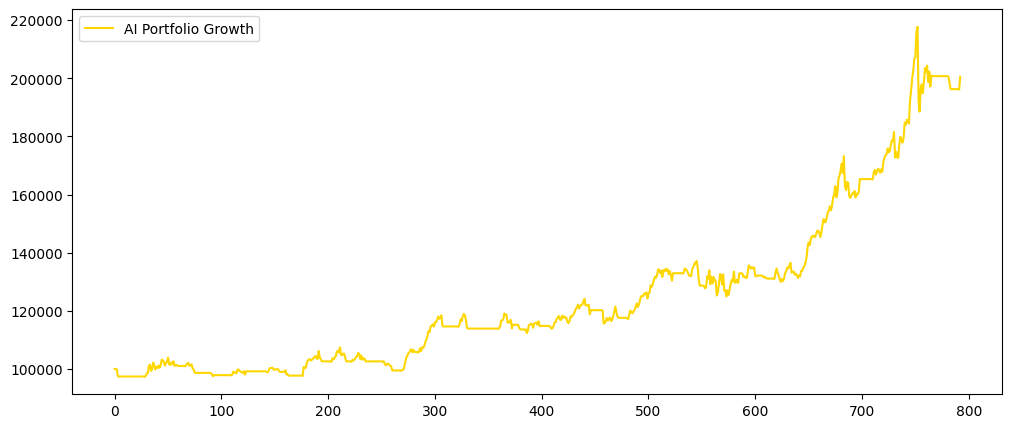

In [61]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1. INSTITUTIONAL DATA SOURCING
gold = yf.download('GC=F', start='2010-01-01', auto_adjust=True)
usd_inr = yf.download('INR=X', start='2010-01-01', auto_adjust=True)

data = pd.DataFrame({
    'Gold_Price_USD': gold['Close'].squeeze(),
    'USD_INR': usd_inr['Close'].squeeze()
}).dropna()

# 2. ADVANCED FEATURE ENGINEERING (Institutional Suite)
data['Gold_Price_INR'] = data['Gold_Price_USD'] * data['USD_INR']

# Trend & Momentum
data['MA10'] = data['Gold_Price_INR'].rolling(10).mean()
data['EMA10'] = data['Gold_Price_INR'].ewm(span=10).mean()
data['MA50'] = data['Gold_Price_INR'].rolling(50).mean()
data['Momentum'] = data['Gold_Price_INR'] - data['Gold_Price_INR'].shift(10)

# Volatility & Bollinger Bands
data['STD10'] = data['Gold_Price_INR'].rolling(10).std()
data['Upper_Band'] = data['MA10'] + (data['STD10'] * 2)
data['Lower_Band'] = data['MA10'] - (data['STD10'] * 2)

# RSI (Overbought/Oversold)
delta = data['Gold_Price_INR'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
data['RSI'] = 100 - (100 / (1 + (gain/(loss + 1e-9))))

data = data.dropna()

# 3. PREPROCESSING
features = ['Gold_Price_USD', 'USD_INR', 'EMA10', 'MA50', 'Momentum', 'STD10', 'RSI']
f_scaler, t_scaler = MinMaxScaler(), MinMaxScaler()
scaled_f = f_scaler.fit_transform(data[features])
scaled_t = t_scaler.fit_transform(data[['Gold_Price_INR']])

def create_seq(f, t, seq=60):
    X_s, y_s = [], []
    for i in range(seq, len(f)):
        X_s.append(f[i-seq:i])
        y_s.append(t[i])
    return np.array(X_s), np.array(y_s)

X, y = create_seq(scaled_f, scaled_t)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# 4. DEEP LEARNING MODEL
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True), Dropout(0.3),
    LSTM(64), Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)

# 5. RESULTS & PERFORMANCE
preds = model.predict(X_test)
act_p = t_scaler.inverse_transform(y_test)
pred_p = t_scaler.inverse_transform(preds)

# Backtest with Transaction Costs
bal, equity = 100000.0, []
pos, qty, buy_p = None, 0, 0
for i in range(1, len(pred_p)):
    curr, p_now, p_prev = act_p[i][0], pred_p[i][0], pred_p[i-1][0]
    if pos == 'LONG' and curr < buy_p * 0.98: # Stop Loss
        bal = qty * curr * 0.999; qty, pos = 0, None
    if p_now > p_prev * 1.002 and pos is None: # Entry
        qty = bal / (curr * 1.001); buy_p = curr; bal, pos = 0, 'LONG'
    elif p_now < p_prev * 0.998 and pos == 'LONG': # Exit
        bal = qty * curr * 0.999; qty, pos = 0, None
    equity.append(bal if pos is None else qty * curr)

print(f"Institutional Model Final Portfolio: ‡{equity[-1]:.2f}")
plt.figure(figsize=(12,5))
plt.plot(equity, color='gold', label='AI Portfolio Growth')
plt.legend(); plt.show()